## COMPARACIÓN DEFINITIVA — TODAS LAS ESTRATEGIAS EN UNA SOLA GRÁFICA

Este notebook une los backtests de las Fases 5, 6, 7 y 9 en una sola gráfica: Markowitz clásico, Equal Weight, Markowitz+SVR, Markowitz+LSTM, S&P 500, y las dos versiones rebalanceadas out-of-sample de la Fase 9 (Max Sharpe y Min Volatility).

### Advertencia metodológica importante (léela antes de interpretar la gráfica)

No todas estas curvas se calcularon de la misma forma:

- **Markowitz clásico, Equal Weight, Markowitz+SVR, Markowitz+LSTM**: optimizados/entrenados **in-sample** (usan información del periodo completo o del propio periodo de test para estimar `mu`), sin rebalanceo.
- **Markowitz Max Sharpe/Min Vol rebalanceados (Fase 9)**: **out-of-sample** real, con ventana móvil y rebalanceo trimestral.

Mezclarlas sin cuidado sería comparar peras con manzanas. Por eso este notebook **recorta todas las series al mismo rango de fechas** (el periodo donde las 7 coexisten, que es el más corto: el de prueba de SVR/LSTM, 2024 en adelante) y las **renormaliza a $1 en esa fecha de inicio común** — así la comparación visual es justa, aunque el lector debe tener presente que las primeras 4 series siguen beneficiándose de haber "visto" ese periodo durante su optimización/entrenamiento, mientras que las 2 de la Fase 9 nunca lo vieron por adelantado.

Importación de librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path


In [3]:
# ============================================================
# CONFIGURACIÓN
# ============================================================

PROJECT_ROOT = Path.cwd().parent
RESULTS_DIR = PROJECT_ROOT / "results" / "comparacion_definitiva"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MARKOWITZ_BACKTEST = PROJECT_ROOT / "results" / "markowitz" / "backtest_comparison.csv"
SVR_BACKTEST = PROJECT_ROOT / "results" / "svr" / "backtest_markowitz_svr.csv"
LSTM_BACKTEST = PROJECT_ROOT / "results" / "lstm" / "backtest_markowitz_lstm.csv"
OOS_BACKTEST = PROJECT_ROOT / "results" / "backtesting_rebalanceo" / "backtest_oos.csv"

print("Directorio de resultados:", RESULTS_DIR)


Directorio de resultados: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\results\comparacion_definitiva


## Carga de los 4 archivos de backtest guardados

In [4]:
markowitz_bt = pd.read_csv(MARKOWITZ_BACKTEST, index_col=0, parse_dates=True)
svr_bt = pd.read_csv(SVR_BACKTEST, index_col=0, parse_dates=True)
lstm_bt = pd.read_csv(LSTM_BACKTEST, index_col=0, parse_dates=True)
oos_bt = pd.read_csv(OOS_BACKTEST, index_col=0, parse_dates=True)

series_dict = {
    "Markowitz Clásico (in-sample)": markowitz_bt["Max Sharpe"],
    "Equal Weight": markowitz_bt["Equal Weight"],
    "Markowitz + SVR (in-sample)": svr_bt["Markowitz + SVR"],
    "Markowitz + LSTM (in-sample)": lstm_bt["Markowitz + LSTM"],
    "Markowitz Max Sharpe (rebalanceado OOS)": oos_bt["Markowitz Max Sharpe (rebalanceado)"],
    "Markowitz Min Vol (rebalanceado OOS)": oos_bt["Markowitz Min Vol (rebalanceado)"],
    "S&P 500": markowitz_bt["S&P 500"]
}

for name, s in series_dict.items():
    print(f"{name}: {s.index.min().date()} → {s.index.max().date()}")


Markowitz Clásico (in-sample): 2018-01-03 → 2026-08-25
Equal Weight: 2018-01-03 → 2026-08-25
Markowitz + SVR (in-sample): 2018-01-03 → 2026-08-25
Markowitz + LSTM (in-sample): 2018-01-03 → 2026-08-25
Markowitz Max Sharpe (rebalanceado OOS): 2020-01-06 → 2026-08-25
Markowitz Min Vol (rebalanceado OOS): 2020-01-06 → 2026-08-25
S&P 500: 2018-01-03 → 2026-08-25


## Recorte al periodo común y renormalización a $1

Se convierte cada curva de crecimiento acumulado de vuelta a retornos diarios, se recorta al rango de fechas donde **todas** las series tienen datos (el más corto manda), y se vuelve a acumular desde ahí — así todas arrancan en $1 el mismo día.

In [5]:
common_start = max(s.index.min() for s in series_dict.values())
common_end = min(s.index.max() for s in series_dict.values())

print("Periodo común a las 7 estrategias:", common_start.date(), "→", common_end.date())

comparacion_definitiva = pd.DataFrame()

for name, cum_series in series_dict.items():
    daily_returns = cum_series.pct_change().dropna()
    daily_returns_common = daily_returns.loc[common_start:common_end]
    comparacion_definitiva[name] = (1 + daily_returns_common).cumprod()

comparacion_definitiva = comparacion_definitiva.dropna()
comparacion_definitiva.head()


Periodo común a las 7 estrategias: 2020-01-06 → 2026-08-25


,Markowitz Clásico (in-sample),Equal Weight,Markowitz + SVR (in-sample),Markowitz + LSTM (in-sample),Markowitz Max Sharpe (rebalanceado OOS),Markowitz Min Vol (rebalanceado OOS),S&P 500
Date,,,,,,,
2020-01-07,1.002135,1.004136,0.998491,1.002261,0.994075,0.992028,1.000720
2020-01-08,1.008535,1.013712,1.008994,1.007014,1.005875,0.993574,1.005626
2020-01-09,1.017158,1.020640,1.015456,1.014649,1.018865,1.002040,1.012319
2020-01-10,1.015538,1.017619,1.013660,1.012162,1.020265,0.998828,1.009429
2020-01-13,1.030758,1.033498,1.027994,1.025540,1.032840,1.006240,1.016471


## Gráfica: las 7 estrategias, mismo periodo, normalizadas a $1

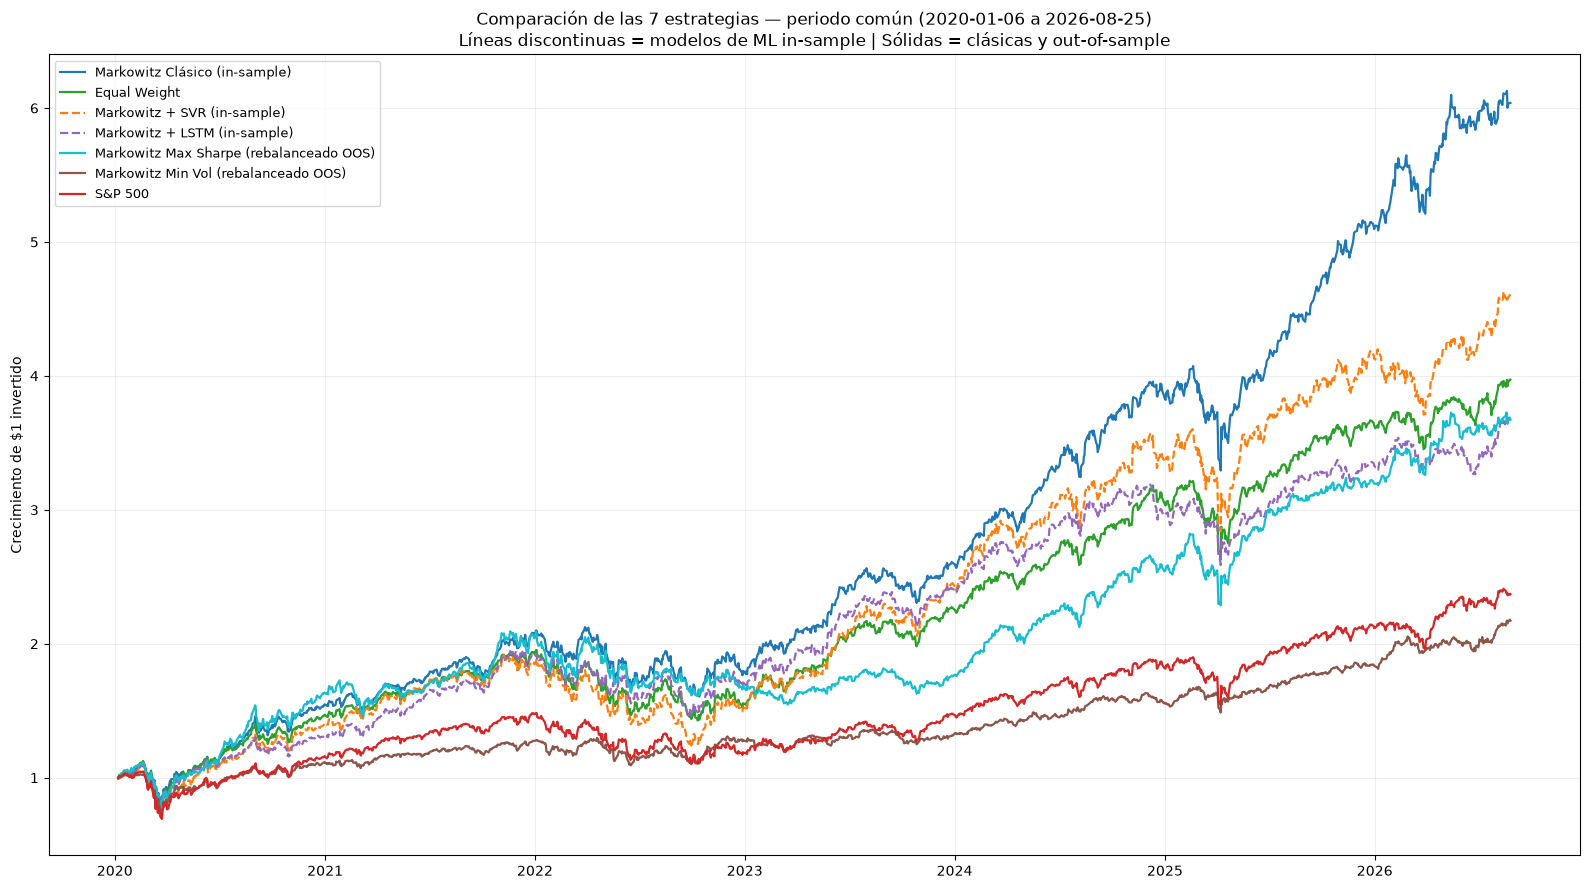

In [6]:
fig, ax = plt.subplots(figsize=(16, 9))

styles = {
    "Markowitz Clásico (in-sample)": dict(color="#1f77b4", linestyle="-"),
    "Equal Weight": dict(color="#2ca02c", linestyle="-"),
    "Markowitz + SVR (in-sample)": dict(color="#ff7f0e", linestyle="--"),
    "Markowitz + LSTM (in-sample)": dict(color="#9467bd", linestyle="--"),
    "Markowitz Max Sharpe (rebalanceado OOS)": dict(color="#17becf", linestyle="-"),
    "Markowitz Min Vol (rebalanceado OOS)": dict(color="#8c564b", linestyle="-"),
    "S&P 500": dict(color="#d62728", linestyle="-")
}

for col in comparacion_definitiva.columns:
    ax.plot(
        comparacion_definitiva.index,
        comparacion_definitiva[col],
        label=col,
        linewidth=1.6,
        **styles.get(col, {})
    )

ax.set_title(
    f"Comparación de las 7 estrategias — periodo común ({common_start.date()} a {common_end.date()})\n"
    "Líneas discontinuas = modelos de ML in-sample | Sólidas = clásicas y out-of-sample",
    fontsize=12
)
ax.set_ylabel("Crecimiento de $1 invertido")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "01_comparacion_7_estrategias.png", dpi=300, bbox_inches="tight")
plt.show()


## Tabla de métricas sobre el periodo común

Al estar todas en la misma ventana de tiempo, esta tabla es la más comparable de todo el proyecto — aunque, como se advirtió arriba, 4 de las 7 estrategias tuvieron ventaja de información (in-sample) que las otras 2 no tuvieron.

In [7]:
def annualized_metrics(cum_returns: pd.Series, risk_free_rate: float = 0.02) -> dict:
    daily_returns = cum_returns.pct_change().dropna()
    ann_return = daily_returns.mean() * 252
    ann_vol = daily_returns.std() * np.sqrt(252)
    sharpe = (ann_return - risk_free_rate) / ann_vol
    max_drawdown = (cum_returns / cum_returns.cummax() - 1).min()
    return {
        "Retorno anualizado": ann_return,
        "Volatilidad anualizada": ann_vol,
        "Sharpe Ratio": sharpe,
        "Máximo Drawdown": max_drawdown
    }

summary_definitivo = pd.DataFrame({
    col: annualized_metrics(comparacion_definitiva[col]) for col in comparacion_definitiva.columns
}).T.sort_values("Sharpe Ratio", ascending=False)

summary_definitivo.round(4)


,Retorno anualizado,Volatilidad anualizada,Sharpe Ratio,Máximo Drawdown
Markowitz Clásico (in-sample),0.2927,0.2043,1.3346,-0.2816
Equal Weight,0.2299,0.2087,1.0058,-0.2998
Markowitz + SVR (in-sample),0.2618,0.2464,0.9814,-0.3524
Markowitz + LSTM (in-sample),0.2193,0.2131,0.9352,-0.3144
Markowitz Max Sharpe (rebalanceado OOS),0.2215,0.2176,0.9258,-0.3170
Markowitz Min Vol (rebalanceado OOS),0.1324,0.1659,0.6772,-0.3013
S&P 500,0.1512,0.2034,0.6452,-0.3392


## Guardar resultados

In [8]:
comparacion_definitiva.to_csv(RESULTS_DIR / "backtest_7_estrategias.csv")
summary_definitivo.to_csv(RESULTS_DIR / "summary_7_estrategias.csv")

print("Resultados guardados en:", RESULTS_DIR)


Resultados guardados en: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\results\comparacion_definitiva
